# CN Patient-Level Quality & Abnormality Profiling

**Goal:** Identify which individual patients in the Cognitively Normal (CN) group actually **do NOT exhibit normal CN features** (i.e. suspected 'imposter' CNs who have focal or global brain atrophy despite being labeled CN).

### Why Patient-Level Screening Matters for SuStaIn:
- SuStaIn uses the CN group to calculate $\text{Mean}_{\text{CN}}$ and $\text{Std}_{\text{CN}}$.
- If abnormal/atrophied subjects are hidden inside the CN group, $\text{Std}_{\text{CN}}$ becomes artificially large, which suppresses Z-scores across all subjects (MCI & AD).
- This notebook evaluates **every CN patient individually** across their 24 brain regions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="white", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

In [2]:
# Load data matching preprocess_sustain_asymmetric.ipynb
raw_data_path = "/Users/khoale/Downloads/Alzheimer_Code/csvs/adni_mri_ucsf_merged.csv"
demographics_path = "/Users/khoale/Downloads/Alzheimer_Code/TABLE_DATA_ADNI/MRI_T1_3D_ADNI1_2_BL_PRE_4_24_2026.csv"

df = pd.read_csv(raw_data_path)
dem_df = pd.read_csv(demographics_path)[['Image Data ID', 'Age', 'Sex']]
df = df.merge(dem_df, left_on='MRI_ImageID', right_on='Image Data ID', how='left')

# 24 Asymmetric regions mapping
biomarker_mapping = {
    "L_Frontal": ["ST15CV", "ST25CV", "ST36CV", "ST39CV", "ST43CV", "ST45CV", "ST46CV", "ST47CV", "ST51CV", "ST55CV", "ST56CV"],
    "L_Temporal": ["ST13CV", "ST24CV", "ST26CV", "ST32CV", "ST40CV", "ST44CV", "ST58CV", "ST60CV", "ST62CV"],
    "L_Parietal": ["ST31CV", "ST49CV", "ST52CV", "ST57CV", "ST59CV"],
    "L_Occipital": ["ST23CV", "ST35CV", "ST38CV", "ST48CV"],
    "L_Cingulate": ["ST14CV", "ST34CV", "ST50CV", "ST54CV"],
    "L_Insula": ["ST129CV"],
    "L_Hippocampus": ["ST29SV"],
    "L_Amygdala": ["ST12SV"],
    "L_Caudate": ["ST16SV"],
    "L_Pallidum": ["ST42SV"],
    "L_Putamen": ["ST53SV"],
    "L_Accumbens": ["ST11SV"],
    "R_Frontal": ["ST74CV", "ST84CV", "ST95CV", "ST98CV", "ST102CV", "ST104CV", "ST105CV", "ST106CV", "ST110CV", "ST115CV"],
    "R_Temporal": ["ST72CV", "ST83CV", "ST85CV", "ST91CV", "ST99CV", "ST103CV", "ST117CV", "ST119CV", "ST121CV"],
    "R_Parietal": ["ST90CV", "ST108CV", "ST111CV", "ST116CV", "ST118CV"],
    "R_Occipital": ["ST82CV", "ST94CV", "ST97CV", "ST107CV"],
    "R_Cingulate": ["ST73CV", "ST93CV", "ST109CV", "ST113CV"],
    "R_Insula": ["ST130CV"],
    "R_Hippocampus": ["ST88SV"],
    "R_Amygdala": ["ST71SV"],
    "R_Caudate": ["ST75SV"],
    "R_Pallidum": ["ST101SV"],
    "R_Putamen": ["ST112SV"],
    "R_Accumbens": ["ST70SV"]
}

all_roi_cols = [col for cols in biomarker_mapping.values() for col in cols]
cols_to_convert = all_roi_cols + ["ST10CV"]
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=["ST10CV"]).copy()

aggregated_df = pd.DataFrame()
aggregated_df["PTID"] = df["PTID"]
aggregated_df["Label"] = df["Label"]
aggregated_df["ICV"] = df["ST10CV"]
aggregated_df["AGE"] = df["Age"]
aggregated_df["Sex_Code"] = df["Sex"].map({'Male': 1, 'Female': 0, 'M': 1, 'F': 0})

for region, cols in biomarker_mapping.items():
    aggregated_df[region] = df[cols].sum(axis=1, min_count=1)

# Covariate Regression (ICV + Age + Sex) on CN controls
normalized_df = aggregated_df.copy()
cn_controls = aggregated_df[aggregated_df["Label"] == "CN"].copy()
regions = list(biomarker_mapping.keys())

for region in regions:
    clean_cn = cn_controls.dropna(subset=[region, "ICV", "AGE", "Sex_Code"])
    X_cn = clean_cn[["ICV", "AGE", "Sex_Code"]].values
    y_cn = clean_cn[region].values
    model = LinearRegression().fit(X_cn, y_cn)
    
    X_all = aggregated_df[["ICV", "AGE", "Sex_Code"]].values
    y_all = aggregated_df[region].values
    residuals = y_all - model.predict(X_all)
    normalized_df[region] = residuals + y_cn.mean()

# Compute RAW UNCLIPPED Z-Scores for all subjects
z_df = pd.DataFrame()
z_df["PTID"] = normalized_df["PTID"]
z_df["Label"] = normalized_df["Label"]
z_df["AGE"] = normalized_df["AGE"]
z_df["Sex_Code"] = normalized_df["Sex_Code"]

cn_norm = normalized_df[normalized_df["Label"] == "CN"]
for region in regions:
    mean_cn = cn_norm[region].mean()
    std_cn = cn_norm[region].std() + 1e-9
    z_df[region] = (mean_cn - normalized_df[region]) / std_cn

print(f"Loaded & preprocessed {len(z_df[z_df['Label']=='CN'])} CN control subjects across 24 regions.")

Loaded & preprocessed 186 CN control subjects across 24 regions.


--- 
## 1. Patient-Level Abnormality Metrics

For each individual CN patient, we calculate:
1. **`Mean_Z`**: Overall average atrophy level across all 24 regions.
2. **`Max_Z`**: The single worst atrophy Z-score among their 24 regions.
3. **`Abnormal_ROIs_Z15`**: Count of regions with moderate atrophy ($Z > 1.5$).
4. **`Abnormal_ROIs_Z20`**: Count of regions with clear atrophy ($Z > 2.0$).
5. **`Abnormal_ROIs_Z25`**: Count of regions with severe atrophy ($Z > 2.5$).
6. **`Top_Atrophied_Region`**: Name of the region where the patient shows the highest atrophy.

In [3]:
# Filter only CN controls for patient-level evaluation
cn_patients = z_df[z_df["Label"] == "CN"].copy()

cn_patients["Mean_Z"] = cn_patients[regions].mean(axis=1)
cn_patients["Max_Z"] = cn_patients[regions].max(axis=1)
cn_patients["Min_Z"] = cn_patients[regions].min(axis=1)  # negative Z means larger volume than CN average

cn_patients["Abnormal_ROIs_Z15"] = (cn_patients[regions] > 1.5).sum(axis=1)
cn_patients["Abnormal_ROIs_Z20"] = (cn_patients[regions] > 2.0).sum(axis=1)
cn_patients["Abnormal_ROIs_Z25"] = (cn_patients[regions] > 2.5).sum(axis=1)

# Find top atrophied region per patient
cn_patients["Top_Atrophied_Region"] = cn_patients[regions].idxmax(axis=1)

# Calculate Mahalanobis Distance for multivariate anomaly detection
cn_matrix = cn_patients[regions].values
cn_mean = np.mean(cn_matrix, axis=0)
cn_cov = np.cov(cn_matrix, rowvar=False)
inv_cov = np.linalg.pinv(cn_cov)

dists = []
for i in range(len(cn_matrix)):
    diff = cn_matrix[i] - cn_mean
    dists.append(np.sqrt(diff.dot(inv_cov).dot(diff)))
cn_patients["Mahalanobis_Dist"] = dists

print(f"Computed patient-level metrics for {len(cn_patients)} CN subjects.")

Computed patient-level metrics for 186 CN subjects.


--- 
## 2. Patient Breakdown: Clean Controls vs. Abnormal CN Subjects

We classify CN subjects into 3 categories:
- **Normal / Clean CN:** No region has $Z > 2.0$ and Mean $Z < 0.5$.
- **Focal Atrophy CN:** 1 or 2 regions have $Z > 2.0$ (localized atrophy in specific structures).
- **Multi-Region / Severe Atrophy CN (Imposter CNs):** $\ge 3$ regions have $Z > 2.0$ OR Mean $Z > 1.0$ (globally atrophied brain).

In [4]:
def classify_cn_patient(row):
    if row["Abnormal_ROIs_Z20"] >= 3 or row["Mean_Z"] >= 1.0:
        return "Severe / Multi-Region Abnormal"
    elif row["Abnormal_ROIs_Z20"] >= 1:
        return "Focal Abnormal (1-2 ROIs)"
    else:
        return "Clean / Normal CN"

cn_patients["CN_Quality_Status"] = cn_patients.apply(classify_cn_patient, axis=1)

status_counts = cn_patients["CN_Quality_Status"].value_counts()
print("=== Summary of CN Patient Quality Breakdown ===")
for status, count in status_counts.items():
    pct = (count / len(cn_patients)) * 100
    print(f" - {status}: {count} patients ({pct:.1f}%)")

=== Summary of CN Patient Quality Breakdown ===
 - Clean / Normal CN: 149 patients (80.1%)
 - Focal Abnormal (1-2 ROIs): 27 patients (14.5%)
 - Severe / Multi-Region Abnormal: 10 patients (5.4%)


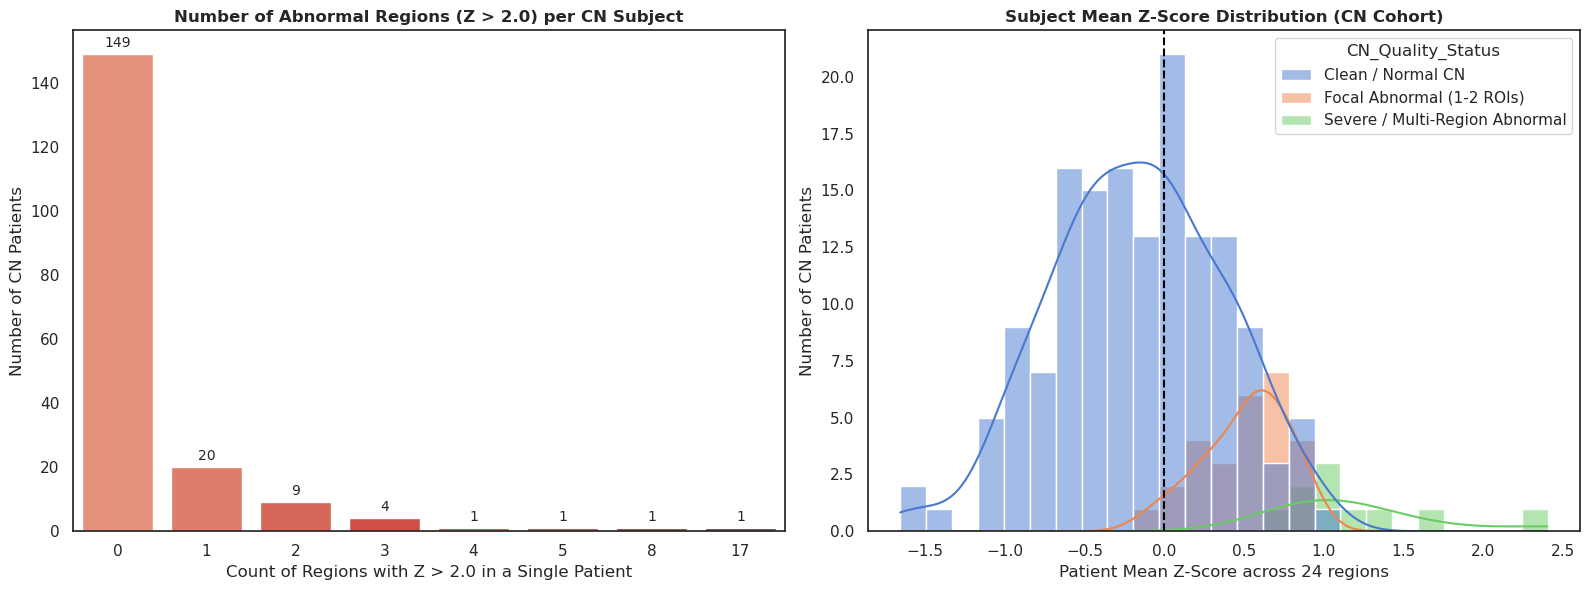

In [5]:
# Visualizing Patient Abnormality Counts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of abnormal ROIs (Z > 2.0) per CN Patient
roi_counts = cn_patients["Abnormal_ROIs_Z20"].value_counts().sort_index()
sns.barplot(x=roi_counts.index, y=roi_counts.values, palette="Reds_d", ax=axes[0])
axes[0].set_title("Number of Abnormal Regions (Z > 2.0) per CN Subject", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Count of Regions with Z > 2.0 in a Single Patient")
axes[0].set_ylabel("Number of CN Patients")

# Annotate bar counts
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

# Plot 2: Distribution of Mean Z-score colored by Quality Status
sns.histplot(data=cn_patients, x="Mean_Z", hue="CN_Quality_Status", kde=True, bins=25, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--", label="Ideal Baseline (Mean Z = 0)")
axes[1].set_title("Subject Mean Z-Score Distribution (CN Cohort)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Patient Mean Z-Score across 24 regions")
axes[1].set_ylabel("Number of CN Patients")

plt.tight_layout()
plt.show()

--- 
## 3. Visual Heatmap of All CN Patients (Sorted by Abnormality)

This heatmap displays **every single CN patient** (Rows) across all **24 Brain Regions** (Columns).
- **Rows** are sorted from top (cleanest normal subjects) to bottom (most abnormal atrophied CN subjects).
- **Color Bar:** Blue/White = Normal (Z ~ 0 or negative), Yellow/Red = Atrophy (Z > 1.5, Z > 2.0).

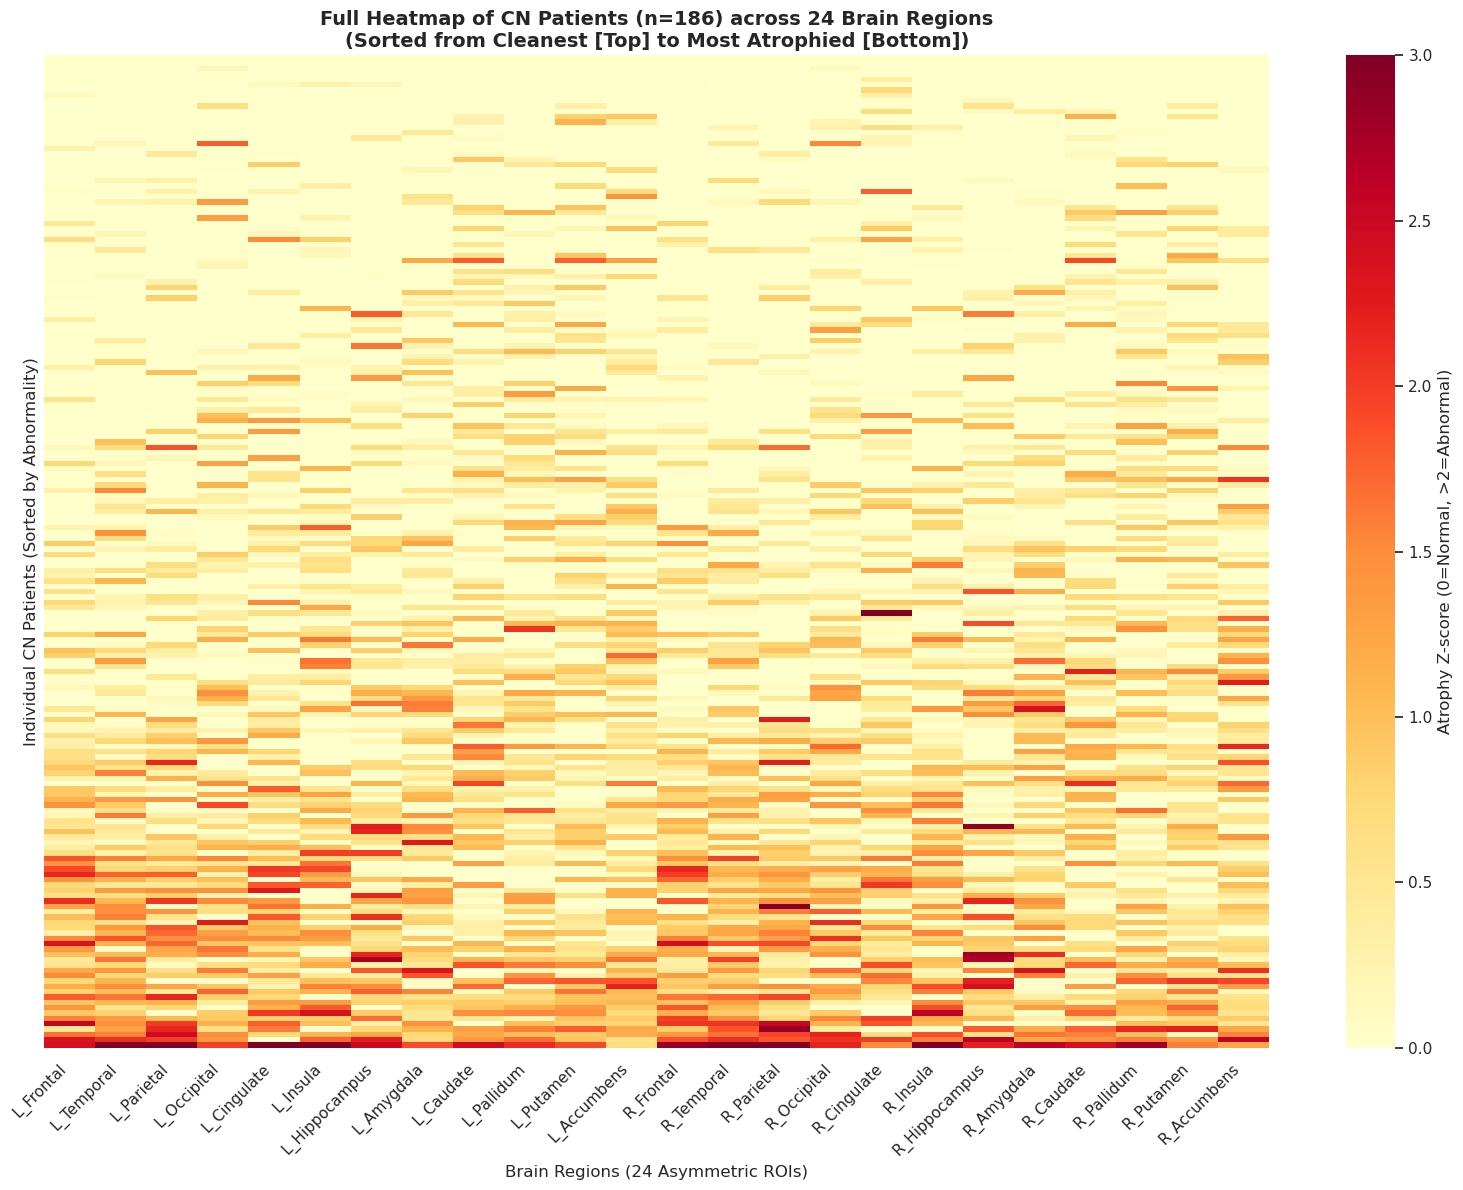

In [6]:
# Sort CN patients by Mean Z-score from cleanest to most abnormal
sorted_cn = cn_patients.sort_values(by="Mean_Z", ascending=True)

plt.figure(figsize=(16, 12))
heatmap_data = sorted_cn[regions]
sns.heatmap(heatmap_data, cmap="YlOrRd", vmin=0, vmax=3.0,
            cbar_kws={'label': 'Atrophy Z-score (0=Normal, >2=Abnormal)'},
            yticklabels=False)

plt.title("Full Heatmap of CN Patients (n=186) across 24 Brain Regions\n(Sorted from Cleanest [Top] to Most Atrophied [Bottom])",
          fontsize=14, fontweight="bold")
plt.xlabel("Brain Regions (24 Asymmetric ROIs)", fontsize=12)
plt.ylabel("Individual CN Patients (Sorted by Abnormality)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

--- 
## 4. List of Suspected 'Imposter' CN Patients

Below are the **most abnormal CN subjects** in the dataset who have multiple atrophied regions or high global atrophy despite their CN label.

In [7]:
# Rank and display the top 20 most abnormal CN patients
abnormal_cn_list = cn_patients.sort_values(by=["Abnormal_ROIs_Z20", "Mean_Z"], ascending=[False, False])

display_cols = ["PTID", "AGE", "Sex_Code", "CN_Quality_Status", "Mean_Z", "Max_Z",
                "Abnormal_ROIs_Z15", "Abnormal_ROIs_Z20", "Abnormal_ROIs_Z25",
                "Top_Atrophied_Region", "Mahalanobis_Dist"]

print("=== Top 20 Most Abnormal CN Subjects (Candidate Outliers / Imposter CNs) ===")
abnormal_cn_list[display_cols].head(20)

=== Top 20 Most Abnormal CN Subjects (Candidate Outliers / Imposter CNs) ===


,PTID,AGE,Sex_Code,CN_Quality_Status,Mean_Z,Max_Z,Abnormal_ROIs_Z15,Abnormal_ROIs_Z20,Abnormal_ROIs_Z25,Top_Atrophied_Region,Mahalanobis_Dist
558,153_S_4139,71,0,Severe / Multi-Region Abnormal,2.404766,3.695091,22,17,10,R_Temporal,5.503293
313,072_S_4103,71,1,Severe / Multi-Region Abnormal,1.632647,2.606611,15,8,2,R_Hippocampus,5.598061
379,099_S_0090,70,1,Severe / Multi-Region Abnormal,1.097277,2.557162,7,5,2,L_Frontal,4.943792
566,941_S_1195,77,1,Severe / Multi-Region Abnormal,1.201546,2.849915,10,4,1,R_Parietal,5.447948
199,033_S_0734,73,1,Severe / Multi-Region Abnormal,1.014281,2.597609,5,3,1,R_Insula,4.331033
480,128_S_0863,79,1,Severe / Multi-Region Abnormal,0.846163,2.358178,7,3,0,R_Amygdala,5.064343
381,099_S_0352,77,0,Severe / Multi-Region Abnormal,0.812871,2.802987,3,3,1,R_Hippocampus,4.403663
18,005_S_0610,79,1,Severe / Multi-Region Abnormal,0.633917,2.171240,5,3,0,R_Hippocampus,5.941737
399,109_S_1013,78,1,Severe / Multi-Region Abnormal,1.316277,2.467423,10,2,0,L_Parietal,4.394321
180,029_S_0845,80,1,Focal Abnormal (1-2 ROIs),0.862632,2.381881,5,2,0,R_Hippocampus,5.929592


--- 
## 5. Inspection of Region Vulnerability in Abnormal CN Subjects

Which brain regions are most commonly abnormal among these high-atrophy CN subjects?

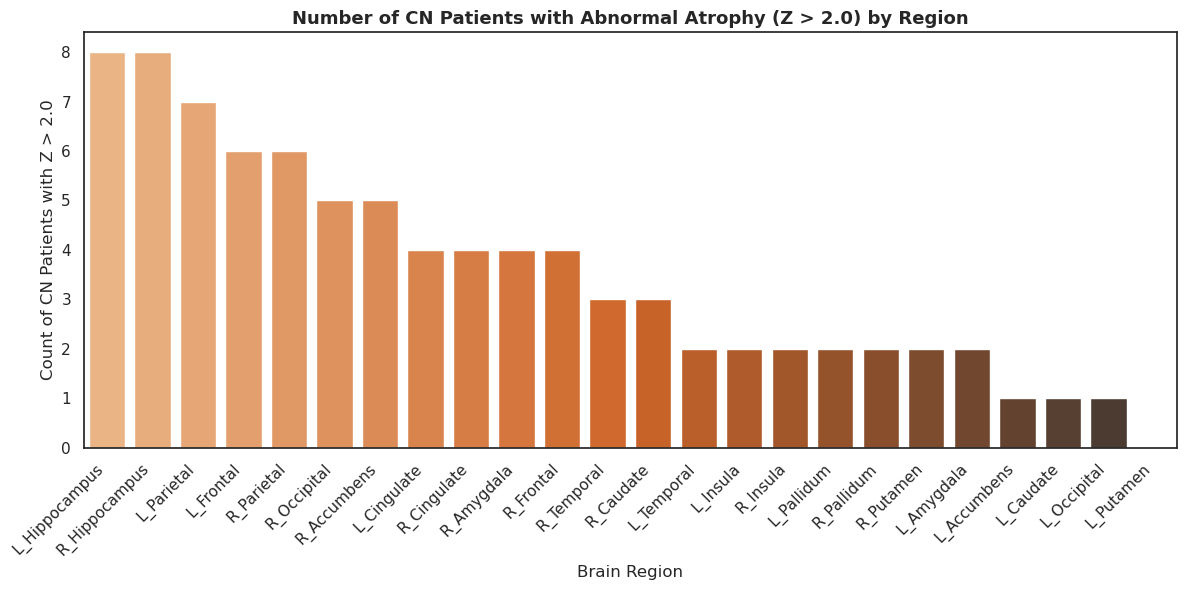

=== Region Abnormality Frequencies in CN Cohort (Z > 2.0) ===
 - L_Hippocampus: 8 CN patients (4.3%)
 - R_Hippocampus: 8 CN patients (4.3%)
 - L_Parietal: 7 CN patients (3.8%)
 - L_Frontal: 6 CN patients (3.2%)
 - R_Parietal: 6 CN patients (3.2%)
 - R_Occipital: 5 CN patients (2.7%)
 - R_Accumbens: 5 CN patients (2.7%)
 - L_Cingulate: 4 CN patients (2.2%)
 - R_Cingulate: 4 CN patients (2.2%)
 - R_Amygdala: 4 CN patients (2.2%)
 - R_Frontal: 4 CN patients (2.2%)
 - R_Temporal: 3 CN patients (1.6%)
 - R_Caudate: 3 CN patients (1.6%)
 - L_Temporal: 2 CN patients (1.1%)
 - L_Insula: 2 CN patients (1.1%)
 - R_Insula: 2 CN patients (1.1%)
 - L_Pallidum: 2 CN patients (1.1%)
 - R_Pallidum: 2 CN patients (1.1%)
 - R_Putamen: 2 CN patients (1.1%)
 - L_Amygdala: 2 CN patients (1.1%)
 - L_Accumbens: 1 CN patients (0.5%)
 - L_Caudate: 1 CN patients (0.5%)
 - L_Occipital: 1 CN patients (0.5%)
 - L_Putamen: 0 CN patients (0.0%)


In [8]:
# Frequency of regions having Z > 2.0 among CN patients
abnormal_counts_per_region = (cn_patients[regions] > 2.0).sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=abnormal_counts_per_region.index, y=abnormal_counts_per_region.values, palette="Oranges_d")
plt.xticks(rotation=45, ha="right")
plt.title("Number of CN Patients with Abnormal Atrophy (Z > 2.0) by Region", fontsize=13, fontweight="bold")
plt.xlabel("Brain Region")
plt.ylabel("Count of CN Patients with Z > 2.0")
plt.tight_layout()
plt.show()

print("=== Region Abnormality Frequencies in CN Cohort (Z > 2.0) ===")
for region, count in abnormal_counts_per_region.items():
    print(f" - {region}: {count} CN patients ({(count/len(cn_patients))*100:.1f}%)")